# Protocol 2: Large-Scale Molecular Assembly Analysis

This notebook follows the workflow behind Figure 2b of [Marshall et al. (2021)](https://doi.org/10.1038/s41467-021-23258-x).

It samples 10,000 molecules from the CBRDB database, computes their assembly indices in parallel, and visualises assembly index against molecular weight as a density heatmap and a grid of example structures.

## Running it

Run this notebook from its own directory so the figures it saves land beside
it. In JupyterLab:

```bash
cd examples/protocols/2
jupyter lab protocol_2.ipynb
```

Or headlessly, which is how the committed outputs were produced:

```bash
cd examples/protocols/2
jupyter nbconvert --to notebook --execute --inplace protocol_2.ipynb
```

Use **Run All** so the total-time cell at the end measures the whole workflow.

This is the longest-running protocol. It downloads the CBRDB dataset over the network on the first run and uses every CPU core. Lower `N_SAMPLES` for a quick look; see the [parallel calculations guide](https://assemblytheorytools.readthedocs.io/en/latest/guide/parallel.html) for tuning the worker count.

## Timing

The heavy steps below start with the `%%time` cell magic. Read the **Wall
time** it reports. The parallel steps spread work across every CPU core, and
`%%time` counts CPU time for the notebook's own process only, not the worker
pool, so wall time is the figure to compare. Expect this notebook to take many minutes at the default sample size. The times shown were
recorded on a 28-core machine and will differ on yours.

In [1]:
%matplotlib inline
import os
import time

import matplotlib.pyplot as plt
from IPython.display import display

import assemblytheorytools as att

print(f"CPU cores available: {os.cpu_count()}")
_t_start = time.perf_counter()

CPU cores available: 28


## Parameters

In [2]:
# Number of molecules to sample from CBRDB. The default reproduces the paper;
# lower it (e.g. 1_000) for a quick run.
N_SAMPLES = 10_000

# Assembly-index settings shared by the parallel calculation:
#   strip_hydrogen - remove hydrogens before the search
#   timeout        - per-molecule limit in seconds
#   exact          - return -1 on timeout instead of an upper bound
AI_SETTINGS = {'strip_hydrogen': True, 'timeout': 120.0, 'exact': True}

# Molecule grid: only short nicknames are readable as labels.
MAX_NAME_LENGTH = 14
N_GRID = 9
N_COLS = 3

### 1. Data acquisition

`att.sample_cbrdb` downloads the CBRDB dataset and returns a random sample as a
DataFrame with `smiles`, `molecular_weight` and `nickname` columns.

In [3]:
%%time
sample = att.sample_cbrdb(n_samples=N_SAMPLES)
sample.head()

CPU times: user 687 ms, sys: 93.1 ms, total: 780 ms
Wall time: 11.4 s


,compound_id,nickname,smiles,molecular_weight,n_heavy_atoms,n_bonds
0,C01186,"(3S,5S)-3,5-Diaminohexanoate",C[C@H](N)C[C@H](N)CC(=O)O,146.190,10,9
1,C18524,Empenthrin,C#CC(OC(=O)C1C(C=C(C)C)C1(C)C)/C(C)=C/CC,274.404,20,20
2,C21138,trans-2-Octenal,CCCCC/C=C/C=O,126.199,9,8
3,C19443,Methyl acrylate,C=CC(=O)OC,86.090,6,5
4,C16788,Pyriculol,C/C=C/[C@H](O)[C@H](O)/C=C/c1cccc(O)c1C=O,248.278,18,18


### 2. Parallel computation

Two parallel passes, timed separately. First convert every SMILES to a graph;
`att.mp_calc` maps a function across all cores. Because the worker pool pickles
the function by reference, `att.smi_to_nx` works here (it is importable from the
installed package), whereas a function defined in this notebook would not.

In [4]:
%%time
graphs = att.mp_calc(att.smi_to_nx, sample['smiles'])

CPU times: user 585 ms, sys: 62.6 ms, total: 648 ms
Wall time: 2.5 s


Then compute the assembly index of every graph in parallel.

In [5]:
%%time
sample['assembly_index'] = att.calculate_assembly_index_parallel(
    graphs, settings=AI_SETTINGS,
)[0]

CPU times: user 3.43 s, sys: 282 ms, total: 3.72 s
Wall time: 8.43 s


### 3. Data filtering

Keep only exact results with an assembly index of 1 or more. This drops the
timeouts (negative) and the valid but trivial zero-index case from the plotted
subset.

In [6]:
n_before = len(sample)
sample = sample[sample['assembly_index'] >= 1].reset_index(drop=True)
print(f"Kept {len(sample)} of {n_before} molecules (AI >= 1)")

Kept 9906 of 10000 molecules (AI >= 1)


### 4. Heatmap

A 2D density heatmap of assembly index against molecular weight. A density plot
is used instead of a scatter because 10,000 points would be unreadable as
markers.

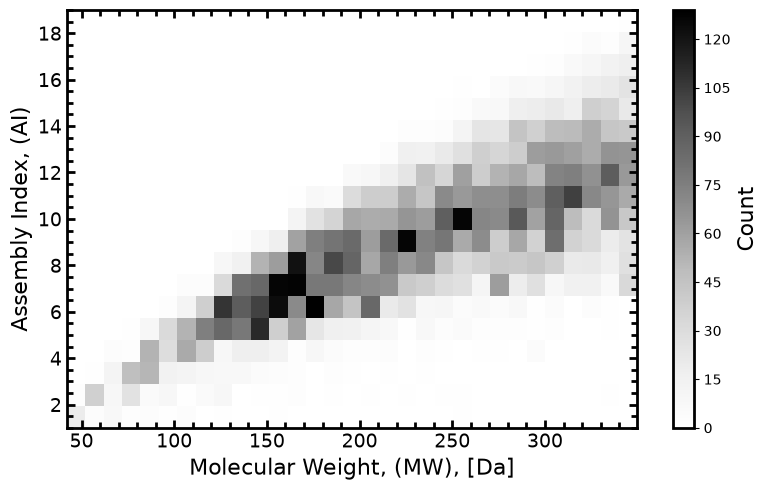

In [7]:
# One x-bin per 10 Da band, one y-bin per distinct assembly index.
n_x_bins = len(set(int(x) // 10 * 10 for x in sample['molecular_weight']))
n_y_bins = len(set(sample['assembly_index']))

fig, ax = att.plot_heatmap(
    sample['molecular_weight'].to_numpy(),
    sample['assembly_index'].to_numpy(),
    "Molecular Weight, (MW), [Da]",
    "Assembly Index, (AI)",
    nbins=(n_x_bins, n_y_bins),
    c_map='Greys',
)
plt.savefig("assembly_index_heatmap.png", dpi=300)
plt.savefig("assembly_index_heatmap.svg")
plt.show()

*Assembly index against molecular weight across the sampled CBRDB molecules, as a density plot.*

### 5. Molecule grid

Pick nine short-named molecules, sort them by assembly index, and draw them on a
grid. Sorting once keeps each structure, label and index aligned.

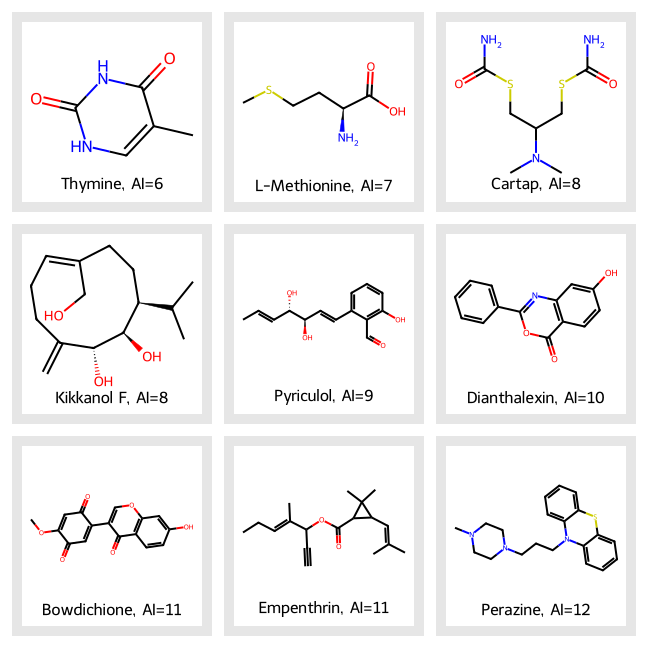

In [8]:
selected = sample[sample['nickname'].str.len() <= MAX_NAME_LENGTH].head(N_GRID)
selected = selected.sort_values('assembly_index').reset_index(drop=True)

labs = [f"{row.nickname}, AI={row.assembly_index}" for row in selected.itertuples()]
smis = selected['smiles'].tolist()

img = att.draw_mol_grid_box(
    smis, legends=labs, n_cols=N_COLS,
    sort_by=selected['assembly_index'].tolist(),
)
img.save("molecule_grid.png")
display(img)

*A subset of the analysed molecules with their nicknames and assembly indices, sorted by index.*

In [9]:
print(f"Total wall time: {time.perf_counter() - _t_start:.1f} s")

Total wall time: 22.8 s


## Related documentation

* [Parallel calculations](https://assemblytheorytools.readthedocs.io/en/latest/guide/parallel.html) — `mp_calc` and `calculate_assembly_index_parallel`.
* [Complexity scores](https://assemblytheorytools.readthedocs.io/en/latest/guide/complexity.html) — comparing assembly index with other measures.